Second try. differnt loop. only lambda hyperparameter, no lag

In [40]:
import pandas as pd
import numpy as np
from scipy import stats

# Load both datasets
df_eelbrain = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran04\decoder_slow.csv')
df_ridge = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_SLOW.csv')

# Merge on subject to compare
comparison_df = pd.merge(
    df_eelbrain[['subject', 'r']],
    df_ridge[['subject', 'cv_mean_test_r_star']],
    on='subject',
    how='inner'
)

# Display comparison
print(comparison_df)
print("Mean + std r:", comparison_df["r"].mean(), comparison_df["r"].std())
print("Mean + std cv_mean_test_r_star:", comparison_df["cv_mean_test_r_star"].mean(), comparison_df["cv_mean_test_r_star"].std())

# Basic statistics
print("\nComparison Statistics:")
print(f"Correlation between 'r' and 'cv_mean_test_r_star': {comparison_df['r'].corr(comparison_df['cv_mean_test_r_star']):.4f}")
print(f"\nDifference (r - cv_mean_test_r_star):")
print((comparison_df['r'] - comparison_df['cv_mean_test_r_star']).describe())

# --- subject-wise diff ---
comparison_df = comparison_df.dropna(subset=["r", "cv_mean_test_r_star"]).copy()
comparison_df["diff"] = comparison_df["r"] - comparison_df["cv_mean_test_r_star"]

diff = comparison_df["diff"].to_numpy()

print("N subjects:", len(diff))
print("Mean diff (eelbrain - ridge):", diff.mean())

# --- Paired t-test (two-sided) ---
t_stat, p_two = stats.ttest_rel(comparison_df["r"], comparison_df["cv_mean_test_r_star"], alternative='less')
print("\nPaired t-test (two-sided):")
print("t =", t_stat, "p =", p_two)

# --- One-tailed p for H1: eelbrain > ridge ---
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
print("\nOne-tailed test H1: eelbrain > ridge:")
print("t =", t_stat, "p_one =", p_one)

# --- Effect size (Cohen's dz for paired designs) ---
dz = diff.mean() / diff.std(ddof=1)
print("\nCohen's dz:", dz)


    subject         r  cv_mean_test_r_star
0        33  0.034412             0.005824
1        34  0.217352             0.278276
2        36  0.178263             0.129232
3        38 -0.091334            -0.055270
4        39  0.265623             0.286689
5        40  0.117986             0.191699
6        41  0.011444            -0.003234
7        42  0.066268            -0.030136
8        43  0.054456             0.238199
9        44 -0.042397             0.079360
10       45 -0.093299            -0.001971
11       47  0.019612            -0.091020
12       48  0.127416             0.204055
13       49  0.041077             0.227122
14       50  0.031878             0.054516
15       51  0.349576             0.262842
16       52 -0.161683             0.087870
17       54  0.082481             0.165432
18       55  0.064350             0.031460
19       56 -0.055040            -0.054817
20       57 -0.093377             0.073298
21       58  0.219792             0.306391
22       59

In [39]:
import pandas as pd
import numpy as np
from scipy import stats

# Load both datasets
df_ridge = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_FAST.csv')
df_eelbrain = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\decoder_fast.csv')
# Merge on subject to compare
comparison_df = pd.merge(
    df_eelbrain[['subject', 'r']],
    df_ridge[['subject', 'cv_mean_test_r_star']],
    on='subject',
    how='inner'
)

# Display comparison
print(comparison_df)
print("Mean + std r:", comparison_df["r"].mean(), comparison_df["r"].std())
print("Mean + std cv_mean_test_r_star:", comparison_df["cv_mean_test_r_star"].mean(), comparison_df["cv_mean_test_r_star"].std())

# Basic statistics
print("\nComparison Statistics:")
print(f"Correlation between 'r' and 'cv_mean_test_r_star': {comparison_df['r'].corr(comparison_df['cv_mean_test_r_star']):.4f}")
print(f"\nDifference (r - cv_mean_test_r_star):")
print((comparison_df['r'] - comparison_df['cv_mean_test_r_star']).describe())

# --- subject-wise diff ---
comparison_df = comparison_df.dropna(subset=["r", "cv_mean_test_r_star"]).copy()
comparison_df["diff"] = comparison_df["r"] - comparison_df["cv_mean_test_r_star"]

diff = comparison_df["diff"].to_numpy()

print("N subjects:", len(diff))
print("Mean diff (eelbrain - ridge):", diff.mean())

# --- Paired t-test (two-sided) ---
t_stat, p_two = stats.ttest_rel(comparison_df["r"], comparison_df["cv_mean_test_r_star"], alternative='two-sided')
print("\nPaired t-test (two-sided):")
print("t =", t_stat, "p =", p_two)

# --- One-tailed p for H1: eelbrain > ridge ---
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
print("\nOne-tailed test H1: eelbrain > ridge:")
print("t =", t_stat, "p_one =", p_one)

# --- Effect size (Cohen's dz for paired designs) ---
dz = diff.mean() / diff.std(ddof=1)
print("\nCohen's dz:", dz)


    subject         r  cv_mean_test_r_star
0        33  0.037993             0.000037
1        34 -0.014333             0.060594
2        36 -0.106317            -0.079977
3        38  0.097141             0.177696
4        39  0.219736             0.304257
5        40  0.255995             0.337377
6        41  0.241316             0.233615
7        42  0.028670             0.067039
8        43  0.024272             0.101135
9        44  0.064389             0.076349
10       45  0.027904             0.061157
11       47  0.098147            -0.030297
12       48 -0.014327            -0.037154
13       49  0.149432             0.092627
14       50  0.195484             0.190844
15       51  0.102027             0.022367
16       52  0.023003             0.087334
17       54 -0.015591             0.034821
18       55  0.001541            -0.012063
19       56  0.007938             0.093310
20       57  0.178548             0.242076
21       58  0.128225             0.204046
22       59

In [31]:
import pandas as pd
import numpy as np
from scipy import stats

# Load both datasets
df_ridge = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_ALL.csv')
df_eelbrain = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\decoder_all2.csv')
# Merge on subject to compare
comparison_df = pd.merge(
    df_eelbrain[['subject', "r_model"]],
    df_ridge[['subject', 'cv_mean_test_r_star']],
    on='subject',
    how='inner'
)

# Display comparison
print(comparison_df)
print("Mean + std r_model:", comparison_df["r_model"].mean(), comparison_df["r_model"].std())
print("Mean + std cv_mean_test_r_star:", comparison_df["cv_mean_test_r_star"].mean(), comparison_df["cv_mean_test_r_star"].std())
# Basic statistics
print("\nComparison Statistics:")
#print(f"Correlation between 'r_model' and 'cv_mean_test_r_star': {comparison_df["r_model"].corr(comparison_df['cv_mean_test_r_star']):.4f}")
print(f"\nDifference (r_model - cv_mean_test_r_star):")
print((comparison_df["r_model"] - comparison_df['cv_mean_test_r_star']).describe())

# --- subject-wise diff ---
comparison_df = comparison_df.dropna(subset=["r_model", "cv_mean_test_r_star"]).copy()
comparison_df["diff"] = comparison_df["r_model"] - comparison_df["cv_mean_test_r_star"]

diff = comparison_df["diff"].to_numpy()

print("N subjects:", len(diff))
print("Mean diff (eelbrain - ridge):", diff.mean())

# --- Paired t-test (two-sided) ---
t_stat, p_two = stats.ttest_rel(comparison_df["r_model"], comparison_df["cv_mean_test_r_star"], alternative='two-sided')
print("\nPaired t-test (two-sided):")
print("t =", t_stat, "p =", p_two)

# --- One-tailed p for H1: eelbrain > ridge ---
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
print("\nOne-tailed test H1: eelbrain > ridge:")
print("t =", t_stat, "p_one =", p_one)

# --- Effect size (Cohen's dz for paired designs) ---
dz = diff.mean() / diff.std(ddof=1)
print("\nCohen's dz:", dz)


    subject   r_model  cv_mean_test_r_star
0        33  0.062625            -0.014104
1        34  0.192570             0.112199
2        36  0.002705            -0.016735
3        38 -0.019668            -0.005905
4        39  0.282845             0.167471
5        40  0.103822             0.122706
6        41  0.070248             0.104540
7        42  0.055680             0.023936
8        43  0.149263             0.081030
9        44  0.054125             0.051975
10       45 -0.005594             0.036847
11       47  0.022420             0.122830
12       48  0.184310             0.071748
13       49  0.158018             0.136010
14       50  0.066190             0.089357
15       51  0.277650             0.092654
16       52  0.038393             0.059480
17       54  0.042842             0.073406
18       55  0.036982            -0.019615
19       56 -0.038651            -0.027150
20       57 -0.018631             0.051015
21       58  0.215371             0.107468
22       59

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load both datasets
df_ridge_all = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_ALL.csv')
df_ridge_slow = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_SLOW.csv')
df_ridge_fast = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_FAST.csv')
df_eelbrain_all = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\decoder_all2.csv')
df_eelbrain_slow = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran04\decoder_slow.csv')
df_eelbrain_fast = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\decoder_fast.csv')
# Merge on subject to compare
comparison_df = pd.merge(
    df_eelbrain_all[['subject', "r_model"]],
    df_ridge_all[['subject', 'cv_mean_test_r_star']],
    df_eelbrain_slow[['subject', "r"]],
    df_ridge_slow[['subject', 'cv_mean_test_r_star']],
    df_eelbrain_fast[['subject', "r"]], 
    df_ridge_fast[['subject', 'cv_mean_test_r_star']],
    on='subject',
    how='inner'
)

# Display comparison
print(comparison_df)
print("Mean + std r_model:", comparison_df["r_model"].mean(), comparison_df["r_model"].std())
print("Mean + std cv_mean_test_r_star:", comparison_df["cv_mean_test_r_star"].mean(), comparison_df["cv_mean_test_r_star"].std())
# Basic statistics
print("\nComparison Statistics:")
#print(f"Correlation between 'r_model' and 'cv_mean_test_r_star': {comparison_df["r_model"].corr(comparison_df['cv_mean_test_r_star']):.4f}")
print(f"\nDifference (r_model - cv_mean_test_r_star):")
print((comparison_df["r_model"] - comparison_df['cv_mean_test_r_star']).describe())

# --- subject-wise diff ---
comparison_df = comparison_df.dropna(subset=["r_model", "cv_mean_test_r_star"]).copy()
comparison_df["diff"] = comparison_df["r_model"] - comparison_df["cv_mean_test_r_star"]

diff = comparison_df["diff"].to_numpy()

print("N subjects:", len(diff))
print("Mean diff (eelbrain - ridge):", diff.mean())

# --- Paired t-test (two-sided) ---
t_stat, p_two = stats.ttest_rel(comparison_df["r_model"], comparison_df["cv_mean_test_r_star"], alternative='two-sided')
print("\nPaired t-test (two-sided):")
print("t =", t_stat, "p =", p_two)

# --- One-tailed p for H1: eelbrain > ridge ---
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
print("\nOne-tailed test H1: eelbrain > ridge:")
print("t =", t_stat, "p_one =", p_one)

# --- Effect size (Cohen's dz for paired designs) ---
dz = diff.mean() / diff.std(ddof=1)
print("\nCohen's dz:", dz)


In [8]:
#%matplotlib qt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})


=== PHASIC (FAST) ===
N subjects: 52
mean eel: 0.10019755641588406 std eel: 0.11914819523950923
mean ridge: 0.10936367051817406 std ridge: 0.11921709617650433
mean diff (eel - ridge): -0.009166
95% CI (t-based) for mean diff: [-0.027900, 0.009568]
paired t-test (two-sided): t = -0.9822795124802698 p = 0.3305992417348813
one-tailed H1: eel > ridge: p_one = 0.8347003791325593
Cohen's dz: -0.136217659580207
95% CI (bootstrap) for mean diff: [-0.026946, 0.009349]

=== TONIC (SLOW) ===
N subjects: 52
mean eel: 0.07077123263791242 std eel: 0.11569661412743056
mean ridge: 0.09839227012578664 std ridge: 0.12220025232461716
mean diff (eel - ridge): -0.027621
95% CI (t-based) for mean diff: [-0.053884, -0.001358]
paired t-test (two-sided): t = -2.1113960322016543 p = 0.03965906373801058
one-tailed H1: eel > ridge: p_one = 0.9801704681309947
Cohen's dz: -0.29279794834285694
95% CI (bootstrap) for mean diff: [-0.053028, -0.002164]

=== COMBINED (ALL) ===
N subjects: 52
mean eel: 0.099477469574849

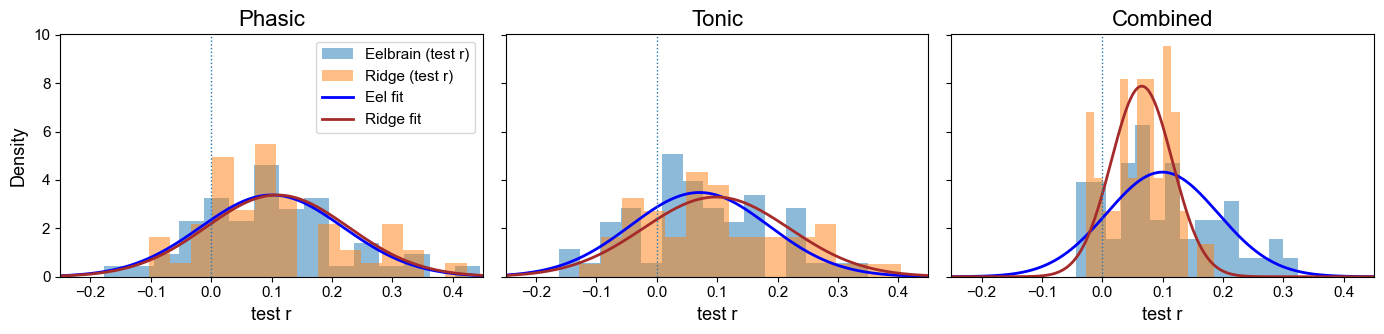

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

# -----------------------------
# Helpers
# -----------------------------
def clean_subject_col(s):
    """
    Make sure subject is an int, whether it looks like 42 or 'sub-042'.
    """
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(int)
    # extract first integer substring
    return s.astype(str).str.extract(r'(\d+)')[0].astype(int)

def pick_col(df, candidates):
    """
    Return the first column name from `candidates` that exists in df.
    """
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}. Available: {list(df.columns)}")

def load_pair(eel_path, ridge_path,
              eel_candidates=("r_model", "r", "r_test", "test_r"),
              ridge_candidates=("cv_mean_test_r_star", "mean_test_r", "r_cv_star", "r_test")):
    """
    Load eelbrain + ridge files and return a merged df with columns:
    subject, eel, ridge
    """
    eel = pd.read_csv(eel_path)
    ridge = pd.read_csv(ridge_path)

    eel_sub = pick_col(eel, ["subject"])
    ridge_sub = pick_col(ridge, ["subject"])

    eel_r = pick_col(eel, eel_candidates)
    ridge_r = pick_col(ridge, ridge_candidates)

    eel = eel[[eel_sub, eel_r]].copy()
    ridge = ridge[[ridge_sub, ridge_r]].copy()

    eel.columns = ["subject", "eel"]
    ridge.columns = ["subject", "ridge"]

    eel["subject"] = clean_subject_col(eel["subject"])
    ridge["subject"] = clean_subject_col(ridge["subject"])

    merged = pd.merge(eel, ridge, on="subject", how="inner").dropna(subset=["eel", "ridge"])
    return merged

def plot_hist_with_gauss(ax, df, title, bins=15, show_legend=True, xlim=(-0.25, 0.45)):
    eel = df["eel"].to_numpy()
    ridge = df["ridge"].to_numpy()

    ax.hist(eel, bins=bins, density=True, alpha=0.5, label="Eelbrain (test r)")
    ax.hist(ridge, bins=bins, density=True, alpha=0.5, label="Ridge (test r)")

    x = np.linspace(xlim[0], xlim[1], 400)

    mu_e, sig_e = norm.fit(eel)
    mu_r, sig_r = norm.fit(ridge)

    ax.plot(x, norm.pdf(x, mu_e, sig_e), linewidth=2,color="blue", label=f"Eel fit")
    ax.plot(x, norm.pdf(x, mu_r, sig_r), linewidth=2, color="brown", label=f"Ridge fit")

    ax.axvline(0, linestyle=":", linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_title(title)
    ax.set_xlabel("test r")
    if show_legend:
        ax.set_ylabel("Density")
        ax.legend()
    #ax.legend(fontsize=8)
import numpy as np
from scipy import stats

def diff_ci_t(diff, alpha=0.05):
    """
    Paired-difference CI for mean(diff) using t distribution.
    """
    diff = np.asarray(diff)
    n = diff.size
    md = diff.mean()
    se = diff.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    return md, (md - tcrit*se, md + tcrit*se)

def diff_ci_bootstrap(diff, n_boot=20000, alpha=0.05, seed=0):
    """
    Bootstrap percentile CI for mean(diff).
    """
    rng = np.random.default_rng(seed)
    diff = np.asarray(diff)
    n = diff.size
    means = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        samp = rng.choice(diff, size=n, replace=True)
        means[b] = samp.mean()
    lo = np.quantile(means, alpha/2)
    hi = np.quantile(means, 1 - alpha/2)
    return diff.mean(), (lo, hi)

def paired_stats_with_ci(df, label, alpha=0.05, do_bootstrap=True):
    diff = (df["eel"] - df["ridge"]).to_numpy()
    n = len(diff)

    t_stat, p_two = stats.ttest_rel(df["eel"], df["ridge"], alternative="two-sided")
    p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
    dz = diff.mean() / diff.std(ddof=1)

    md, (lo, hi) = diff_ci_t(diff, alpha=alpha)

    print(f"\n=== {label} ===")
    print("N subjects:", n)
    print("mean eel:", df["eel"].mean(), "std eel:", df["eel"].std(ddof=1))
    print("mean ridge:", df["ridge"].mean(), "std ridge:", df["ridge"].std(ddof=1))
    print(f"mean diff (eel - ridge): {md:.6f}")
    print(f"{int((1-alpha)*100)}% CI (t-based) for mean diff: [{lo:.6f}, {hi:.6f}]")
    print("paired t-test (two-sided): t =", t_stat, "p =", p_two)
    print("one-tailed H1: eel > ridge: p_one =", p_one)
    print("Cohen's dz:", dz)

    if do_bootstrap:
        md_b, (lo_b, hi_b) = diff_ci_bootstrap(diff, n_boot=20000, alpha=alpha, seed=0)
        print(f"{int((1-alpha)*100)}% CI (bootstrap) for mean diff: [{lo_b:.6f}, {hi_b:.6f}]")



# -----------------------------
# Your paths
# -----------------------------
df_ridge_all_path  = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_ALL.csv"
df_ridge_slow_path = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_SLOW.csv"
df_ridge_fast_path = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_FAST.csv"

df_eel_all_path  = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\decoder_all2.csv"
df_eel_slow_path = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\ran04\decoder_slow.csv"
df_eel_fast_path = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast\ran12\decoder_fast.csv"


# -----------------------------
# Load + stats
# -----------------------------
df_combined = load_pair(df_eel_all_path,  df_ridge_all_path)   # combined
df_tonic    = load_pair(df_eel_slow_path, df_ridge_slow_path)  # tonic (slow)
df_phasic   = load_pair(df_eel_fast_path, df_ridge_fast_path)  # phasic (fast)


# Use it like this (same dfs you already created):
paired_stats_with_ci(df_phasic,   "PHASIC (FAST)")
paired_stats_with_ci(df_tonic,    "TONIC (SLOW)")
paired_stats_with_ci(df_combined, "COMBINED (ALL)")

# -----------------------------
# Plot: 3 histograms (test only)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
plot_hist_with_gauss(axes[0], df_phasic,   "Phasic")
plot_hist_with_gauss(axes[1], df_tonic,    "Tonic", show_legend=False)
plot_hist_with_gauss(axes[2], df_combined, "Combined", show_legend=False)
plt.tight_layout()
plt.show()


In [4]:
import numpy as np
from scipy import stats

# -----------------------------
# Stats helpers for the table
# -----------------------------
def mean_sd_ci_t(x, alpha=0.05):
    """
    Mean ± SD and t-based CI for the population mean.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    m = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    lo = m - tcrit * se
    hi = m + tcrit * se
    return m, sd, lo, hi, n

def fmt_mean_sd(m, sd, nd=3):
    return f"{m:.{nd}f} $\\pm$ {sd:.{nd}f}"

def fmt_ci(lo, hi, nd=3):
    return f"[{lo:.{nd}f}, {hi:.{nd}f}]"

def fmt_p(p):
    if p < 1e-4:
        return f"{p:.1e}"
    return f"{p:.4f}"

def component_row_stats(df, alpha=0.05, nd=3):
    """
    df has columns: eel, ridge
    Returns formatted tuples for Ridge, Eel, Delta rows:
      (mean±SD, 95% CI, p_two_sided)
    """
    eel = df["eel"].to_numpy(dtype=float)
    ridge = df["ridge"].to_numpy(dtype=float)
    diff = eel - ridge

    # Summary stats + CI
    m_r, sd_r, lo_r, hi_r, n = mean_sd_ci_t(ridge, alpha=alpha)
    m_e, sd_e, lo_e, hi_e, _ = mean_sd_ci_t(eel, alpha=alpha)
    m_d, sd_d, lo_d, hi_d, _ = mean_sd_ci_t(diff, alpha=alpha)

    # Two-sided p-values:
    # Ridge/Eel: one-sample t-test vs 0
    p_r = float(stats.ttest_1samp(ridge, popmean=0.0, alternative="two-sided").pvalue)
    p_e = float(stats.ttest_1samp(eel,   popmean=0.0, alternative="two-sided").pvalue)
    # Delta: paired t-test (eel vs ridge)
    p_d = float(stats.ttest_rel(eel, ridge, alternative="two-sided").pvalue)

    ridge_row = (fmt_mean_sd(m_r, sd_r, nd), fmt_ci(lo_r, hi_r, nd), fmt_p(p_r))
    eel_row   = (fmt_mean_sd(m_e, sd_e, nd), fmt_ci(lo_e, hi_e, nd), fmt_p(p_e))
    delta_row = (fmt_mean_sd(m_d, sd_d, nd), fmt_ci(lo_d, hi_d, nd), fmt_p(p_d))

    return ridge_row, eel_row, delta_row, n


def make_latex_table(df_phasic, df_tonic, df_combined, alpha=0.05, nd=3):
    rows = []
    for label, df in [("Phasic", df_phasic), ("Tonic", df_tonic), ("Combined", df_combined)]:
        ridge_row, eel_row, delta_row, n = component_row_stats(df, alpha=alpha, nd=nd)
        rows.append((label, ridge_row, eel_row, delta_row, n))

    def comp_label(lbl, n):  # remove (N=...) if you don't want it
        return f"{lbl} (N={n})"

    latex = []
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"  \centering")
    latex.append(
        r"  \caption{Test correlation comparison between ridge (Eelbrain-matched evaluation) and Eelbrain mTRF decoder."
        r" Values are mean $\pm$ SD across subjects. 95\% CI is for the population mean."
        r" Two-sided one-sample $t$-tests vs.\ 0 are reported for $r^{\mathrm{test}}_{\mathrm{ridge}}$ and $r^{\mathrm{test}}_{\mathrm{eel}}$."
        r" Two-sided paired $t$-tests are reported for $\Delta r_s = r^{\mathrm{test}}_{s,\mathrm{eel}} - r^{\mathrm{test}}_{s,\mathrm{ridge}}$.}"
    )
    latex.append(r"  \label{tab:ridge_vs_trf_stats}")
    latex.append(r"  \begin{tabular}{llccc}")
    latex.append(r"    \toprule")
    latex.append(r"    Component & Quantity & Mean $\pm$ SD & 95\% CI (mean) & $p$ (two-sided) \\")
    latex.append(r"    \midrule")

    for (comp, ridge_row, eel_row, delta_row, n) in rows:
        latex.append(rf"    \multirow{{3}}{{*}}{{{comp_label(comp, n)}}}")
        latex.append(rf"      & Ridge $r^{{\mathrm{{test}}}}$    & {ridge_row[0]} & {ridge_row[1]} & {ridge_row[2]} \\")
        latex.append(rf"      & Eelbrain $r^{{\mathrm{{test}}}}$ & {eel_row[0]} & {eel_row[1]} & {eel_row[2]} \\")
        latex.append(rf"      & $\Delta r$ (eel--ridge)          & {delta_row[0]} & {delta_row[1]} & {delta_row[2]} \\")
        latex.append(r"    \cmidrule(lr){1-5}")

    latex[-1] = r"    \bottomrule"  # replace last cmidrule with bottomrule
    latex.append(r"  \end{tabular}")
    latex.append(r"\end{table}")

    return "\n".join(latex)


# -----------------------------
# Run (with your already-loaded dfs)
# -----------------------------
latex_table = make_latex_table(df_phasic, df_tonic, df_combined, alpha=0.05, nd=3)
print(latex_table)


\begin{table}[htbp]
  \centering
  \caption{Test correlation comparison between ridge (Eelbrain-matched evaluation) and Eelbrain mTRF decoder. Values are mean $\pm$ SD across subjects. 95\% CI is for the population mean. Two-sided one-sample $t$-tests vs.\ 0 are reported for $r^{\mathrm{test}}_{\mathrm{ridge}}$ and $r^{\mathrm{test}}_{\mathrm{eel}}$. Two-sided paired $t$-tests are reported for $\Delta r_s = r^{\mathrm{test}}_{s,\mathrm{eel}} - r^{\mathrm{test}}_{s,\mathrm{ridge}}$.}
  \label{tab:ridge_vs_trf_stats}
  \begin{tabular}{llccc}
    \toprule
    Component & Quantity & Mean $\pm$ SD & 95\% CI (mean) & $p$ (two-sided) \\
    \midrule
    \multirow{3}{*}{Phasic (N=52)}
      & Ridge $r^{\mathrm{test}}$    & 0.109 $\pm$ 0.119 & [0.076, 0.143] & 2.2e-08 \\
      & Eelbrain $r^{\mathrm{test}}$ & 0.100 $\pm$ 0.119 & [0.067, 0.133] & 1.6e-07 \\
      & $\Delta r$ (eel--ridge)          & -0.009 $\pm$ 0.067 & [-0.028, 0.010] & 0.3306 \\
    \cmidrule(lr){1-5}
    \multirow{3}{*}{Tonic

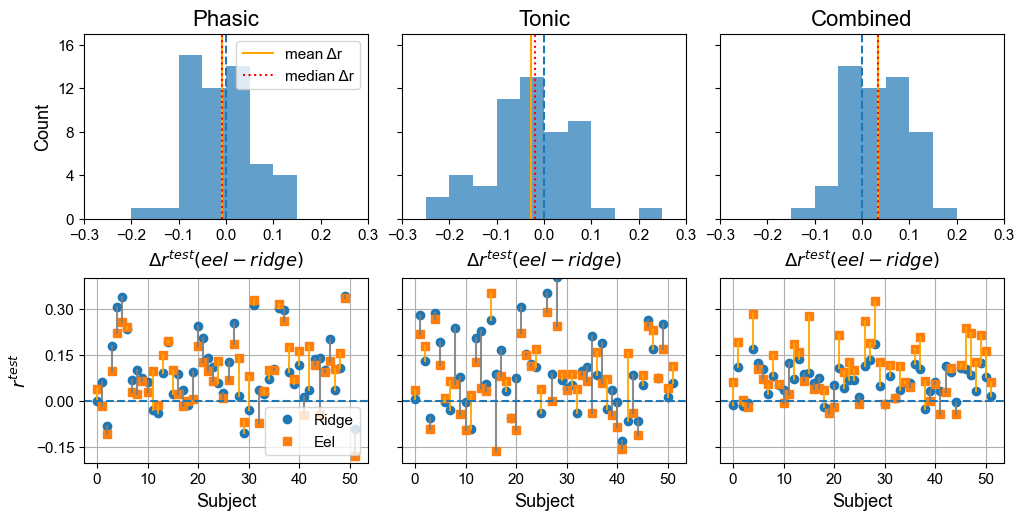

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def _extract_arrays(df):
    eel = df["eel"].to_numpy(dtype=float)
    ridge = df["ridge"].to_numpy(dtype=float)
    mask = np.isfinite(eel) & np.isfinite(ridge)
    eel, ridge = eel[mask], ridge[mask]
    diff = eel - ridge
    return eel, ridge, diff

def plot_hist_and_paired_grid(df_phasic, df_tonic, df_combined,
                              xlim_diff=(-0.3, 0.3),
                              ylim_paired=(-0.2, 0.4),
                              bins=12,
                              figsize=(10, 5.5)):

    dfs = [df_phasic, df_tonic, df_combined]
    col_titles = ["Phasic", "Tonic", "Combined"]

    # --- extract arrays & compute a common hist y-limit ---
    data = []
    all_counts_max = 0
    bin_edges = np.linspace(xlim_diff[0], xlim_diff[1], bins + 1)

    for df in dfs:
        eel, ridge, diff = _extract_arrays(df)
        data.append((eel, ridge, diff))

        counts, _ = np.histogram(diff, bins=bin_edges)
        all_counts_max = max(all_counts_max, int(counts.max()) if counts.size else 0)

    ylim_hist = (0, max(4, all_counts_max + 2))

    # --- figure layout ---
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharey="row")
    fig.subplots_adjust(
        left=0.07, right=0.99, bottom=0.10, top=0.88,
        wspace=0.12, hspace=0.32
    )

    # --- plotting ---
    for j, (title, (eel, ridge, diff)) in enumerate(zip(col_titles, data)):

        # ---------- Row 1: histogram ----------
        ax = axes[0, j]
        ax.hist(diff, bins=bin_edges, density=False, alpha=0.7)

        mean_d = float(np.mean(diff)) if diff.size else np.nan
        med_d  = float(np.median(diff)) if diff.size else np.nan

        ax.axvline(0.0, linestyle="--", linewidth=1.5)
        ax.axvline(mean_d, linestyle="-", linewidth=1.5,
                   label=f"mean Δr ", color="orange")
        ax.axvline(med_d, linestyle=":", linewidth=1.5,
                   label=f"median Δr", color="red")

        ax.set_xlim(*xlim_diff)
        ax.set_ylim(*ylim_hist)
        ax.set_title(title)

        ax.set_xlabel(r"$\Delta r^{test}(eel - ridge)$")

        # fewer y-ticks on histogram
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

        if j == 0:
            ax.set_ylabel("Count")
            ax.legend()
        else:
            ax.set_ylabel("")
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        # ---------- Row 2: paired plot ----------
        ax = axes[1, j]
        n = diff.size
        x = np.arange(n)

        ax.plot(x, ridge, marker="o", linestyle="", label="Ridge")
        ax.plot(x, eel,   marker="s", linestyle="", label="Eel")

        for i in range(n):
            color = "orange" if diff[i] > 0 else "gray"
            ax.plot([x[i], x[i]], [ridge[i], eel[i]],
                    color=color, linewidth=1.5, alpha=0.9)

        ax.axhline(0, linestyle="--", linewidth=1.5)
        ax.set_ylim(*ylim_paired)
        ax.set_xlabel("Subject")

        # fewer y-ticks on paired row too
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        if j == 0:
            ax.set_ylabel(r"$r^{test}$")
            ax.legend()
        else:
            ax.set_ylabel("")
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.grid(True)

    plt.show()


# call:
plot_hist_and_paired_grid(df_phasic, df_tonic, df_combined)


In [8]:
import pandas as pd
import numpy as np
from scipy import stats

# Load both datasets
df_ridge = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_ALL.csv')

# Basic statistics
print("\nComparison Statistics:")
print(f"Correlation between 'cv_mean_test_r_lam0' and 'cv_mean_test_r_star': {df_ridge['cv_mean_test_r_lam0'].corr(df_ridge['cv_mean_test_r_star']):.4f}")
print(f"\nDifference (cv_mean_test_r_lam0 - cv_mean_test_r_star):")
print((df_ridge['cv_mean_test_r_lam0'] - df_ridge['cv_mean_test_r_star']).describe())

# --- subject-wise diff ---
df_ridge = df_ridge.dropna(subset=["cv_mean_test_r_lam0", "cv_mean_test_r_star"]).copy()
df_ridge["diff"] = df_ridge["cv_mean_test_r_lam0"] - df_ridge["cv_mean_test_r_star"]

diff = df_ridge["diff"].to_numpy()

print("N subjects:", len(diff))
print("Mean diff (eelbrain - ridge):", diff.mean())

# --- Paired t-test (one-sided) ---
t_stat, p_one = stats.ttest_rel(df_ridge["cv_mean_test_r_lam0"], df_ridge["cv_mean_test_r_star"], alternative='less')
print("\nPaired t-test (one-sided):")
print("t =", t_stat, "p =", p_one)





Comparison Statistics:
Correlation between 'cv_mean_test_r_lam0' and 'cv_mean_test_r_star': 0.9214

Difference (cv_mean_test_r_lam0 - cv_mean_test_r_star):
count    52.000000
mean     -0.007862
std       0.019866
min      -0.065199
25%      -0.013463
50%      -0.004396
75%       0.002720
max       0.037690
dtype: float64
N subjects: 52
Mean diff (eelbrain - ridge): -0.007862485391581709

Paired t-test (one-sided):
t = -2.8539095908331222 p = 0.0031133209788268483


In [28]:
import pandas as pd
import numpy as np
from scipy import stats

# Load both datasets
df_ridge = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\match_eelbrain_cv\dfk_ridge_eelbrain_ALL.csv')
df_eelbrain = pd.read_csv(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\eelbrain\fast_and_slow\ran10\decoder_all2.csv')
# Merge on subject to compare
comparison_df = pd.merge(
    df_eelbrain[['subject', "r_manual_convolve"]],
    df_ridge[['subject', 'r_refit_all_star']],
    on='subject',
    how='inner'
)

# Display comparison
print(comparison_df)

# Basic statistics
print("\nComparison Statistics:")
#print(f"Correlation between 'r' and 'cv_mean_test_r_star': {comparison_df['r'].corr(comparison_df['cv_mean_test_r_star']):.4f}")
#print(f"Correlation between 'r_manual_convolve' and 'r_refit_all_star': {comparison_df["r_manual_convolve"].corr(comparison_df['r_refit_all_star']):.4f}")
print(f"\nDifference (r_manual_convolve - r_refit_all_star):")
print((comparison_df["r_manual_convolve"] - comparison_df['r_refit_all_star']).describe())

# --- subject-wise diff ---
comparison_df = comparison_df.dropna(subset=["r_manual_convolve", "r_refit_all_star"]).copy()
comparison_df["diff"] = comparison_df["r_manual_convolve"] - comparison_df["r_refit_all_star"]

diff = comparison_df["diff"].to_numpy()

print("N subjects:", len(diff))
print("Mean diff (eelbrain - ridge):", diff.mean())

# --- Paired t-test (two-sided) ---
t_stat, p_two = stats.ttest_rel(comparison_df["r_manual_convolve"], comparison_df["r_refit_all_star"], alternative='two-sided')
print("\nPaired t-test (two-sided):")
print("t =", t_stat, "p =", p_two)

# --- One-tailed p for H1: eelbrain > ridge ---
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
print("\nOne-tailed test H1: eelbrain > ridge:")
print("t =", t_stat, "p_one =", p_one)

# --- Effect size (Cohen's dz for paired designs) ---
dz = diff.mean() / diff.std(ddof=1)
print("\nCohen's dz:", dz)


    subject  r_manual_convolve  r_refit_all_star
0        33           0.229888          0.068537
1        34           0.328255          0.145001
2        36           0.233717          0.098609
3        38           0.208639          0.080503
4        39           0.413873          0.198491
5        40           0.360776          0.150975
6        41           0.276411          0.123435
7        42           0.240462          0.078733
8        43           0.297675          0.133329
9        44           0.219770          0.093093
10       45           0.265492          0.103131
11       47           0.309095          0.171482
12       48           0.379121          0.138462
13       49           0.357057          0.165725
14       50           0.228233          0.120411
15       51           0.500492          0.173809
16       52           0.322648          0.135066
17       54           0.212968          0.088087
18       55           0.265660          0.079955
19       56         